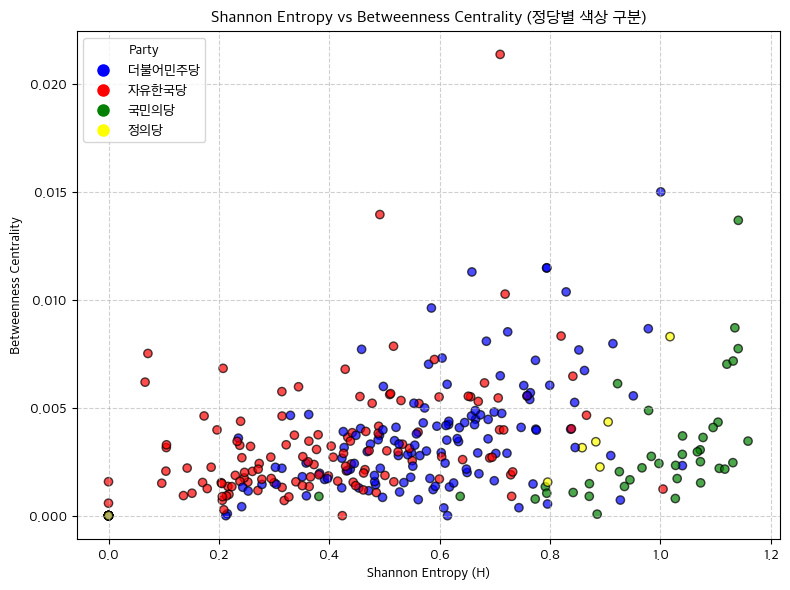

Top 50 nodes for file '의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이전_edge.csv':
 ID Label  Party Reselection District_Type Gender           Role  BetweennessCentrality  ShannonEntropy  AdjustedCentrality  Color
유성엽   유성엽   국민의당          3선           지역구      남 Representative               0.013684        1.140990            0.015613  green
김석기   김석기  자유한국당          초선           지역구      남 Representative               0.021372        0.709566            0.015165    red
우상호   우상호 더불어민주당          3선           지역구      남 Representative               0.015001        1.000560            0.015010   blue
정동영   정동영   국민의당          4선           지역구      남 Representative               0.008704        1.134789            0.009878  green
심재권   심재권 더불어민주당          3선           지역구      남 Representative               0.011486        0.794036            0.009120   blue
홍의락   홍의락 더불어민주당          재선           지역구      남 Representative               0.011472        0.793760            0.009106   blue
최도자   최

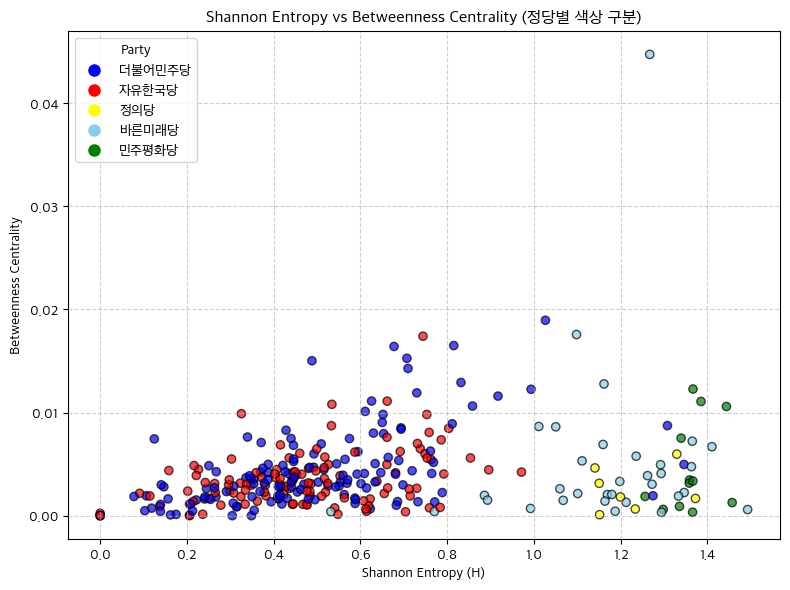

Top 50 nodes for file '의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이후_edge.csv':
 ID Label  Party Reselection District_Type Gender           Role  BetweennessCentrality  ShannonEntropy  AdjustedCentrality   Color
이동섭   이동섭  바른미래당          초선          비례대표      남 Representative               0.044730        1.267323            0.056688 skyblue
정세균   정세균 더불어민주당          6선           지역구      남 Representative               0.018947        1.026816            0.019455    blue
이학재   이학재  바른미래당          3선           지역구      남 Representative               0.017564        1.098469            0.019293 skyblue
정동영   정동영  민주평화당          4선           지역구      남 Representative               0.012278        1.367088            0.016785   green
장병완   장병완  민주평화당          3선           지역구      남 Representative               0.011078        1.385470            0.015348   green
김경진   김경진  민주평화당          초선           지역구      남 Representative               0.010586        1.444087            0.015288   green


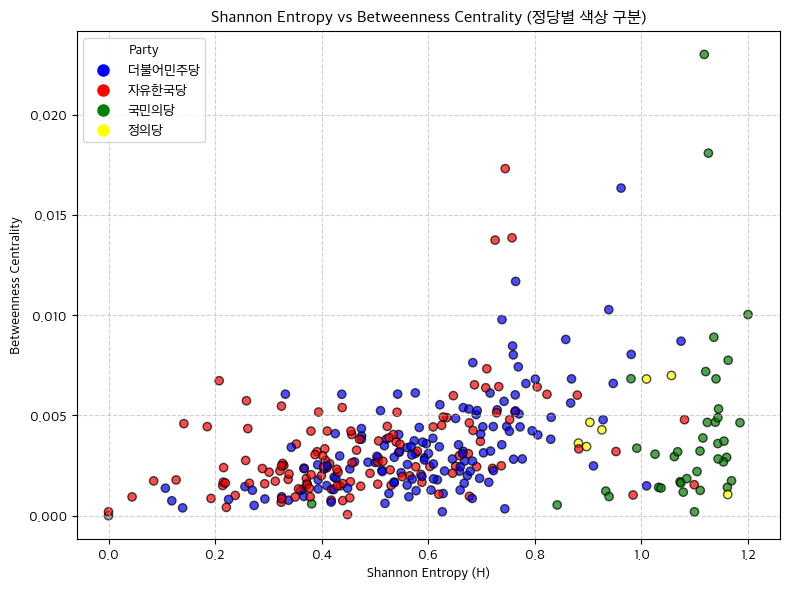

Top 50 nodes for file '의원데이터/전체데이터/제20대_법안별_전체데이터_edge.csv':
 ID Label  Party Reselection District_Type Gender           Role  BetweennessCentrality  ShannonEntropy  AdjustedCentrality  Color
이동섭   이동섭   국민의당          초선          비례대표      남 Representative               0.023010        1.117815            0.025721  green
유성엽   유성엽   국민의당          3선           지역구      남 Representative               0.018086        1.125506            0.020356  green
우상호   우상호 더불어민주당          3선           지역구      남 Representative               0.016342        0.961728            0.015716   blue
김석기   김석기  자유한국당          초선           지역구      남 Representative               0.017311        0.744349            0.012885    red
김경진   김경진   국민의당          초선           지역구      남 Representative               0.010031        1.199900            0.012036  green
이학재   이학재  자유한국당          3선           지역구      남 Representative               0.013860        0.757146            0.010494    red
정동영   정동영   국민의당      

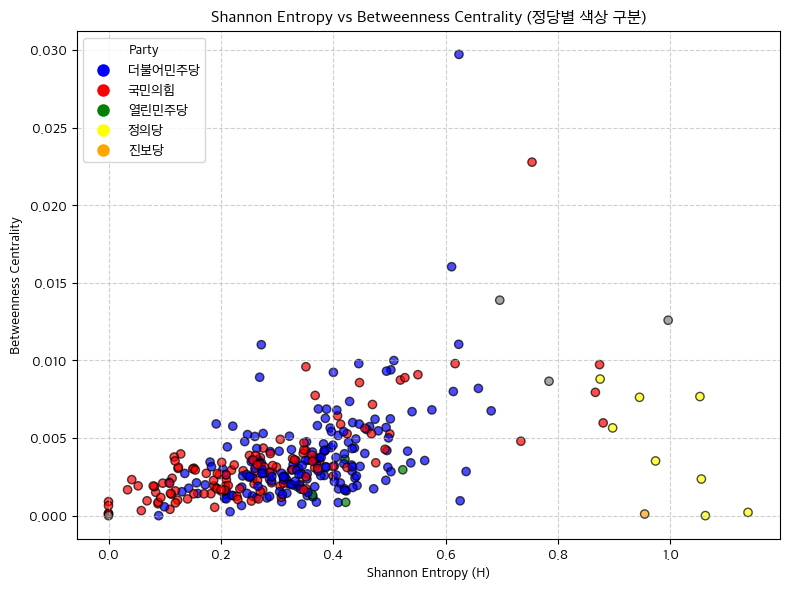

Top 50 nodes for file '의원데이터/전체데이터/제21대_법안별_전체데이터_edge.csv':
 ID Label  Party Reselection District_Type Gender           Role  BetweennessCentrality  ShannonEntropy  AdjustedCentrality  Color
김진표   김진표 더불어민주당          5선           지역구      남 Representative               0.029712        0.623878            0.018537   blue
윤재옥   윤재옥   국민의힘          3선           지역구      남 Representative               0.022772        0.753927            0.017168    red
조정훈   조정훈   시대전환          초선          비례대표      남 Representative               0.012587        0.996266            0.012540   gray
 허영    허영 더불어민주당          초선           지역구      남 Representative               0.016035        0.610790            0.009794   blue
양향자   양향자    무소속          초선           지역구      여 Representative               0.013880        0.696492            0.009667   gray
이용호   이용호   국민의힘          재선           지역구      남 Representative               0.009730        0.874142            0.008506    red
류호정   류호정    정의당      

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager, rc

# 엣지와 노드 CSV 파일 목록 정의
edge_files = [
    '의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이전_edge.csv',
    '의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이후_edge.csv',
    '의원데이터/전체데이터/제20대_법안별_전체데이터_edge.csv',
    '의원데이터/전체데이터/제21대_법안별_전체데이터_edge.csv'
]

node_files = [
    '의원데이터/전체데이터/제20대_법안별_전체데이터_node.csv',
    '의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이후_node.csv',
    '의원데이터/전체데이터/제20대_법안별_전체데이터_node.csv',
    '의원데이터/전체데이터/제21대_법안별_전체데이터_node.csv'
]


# 한글 폰트 설정 (예: Apple SD Gothic Neo)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'  # Mac에서 사용 가능한 폰트

# 함수 정의
def calculate_top_nodes_with_entropy_adjusted_centrality(graph, top_n=20):
    """
    Calculate weighted directed betweenness centrality and adjust it by 
    Shannon Entropy of external party connections.
    Return the top N nodes with their full details by the adjusted centrality.
    """
    # Compute weighted directed betweenness centrality
    betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

    adjusted_centrality = {}
    entropies = []
    entropy_centrality_data = []  # For scatter plot
    parties = []  # Track party information for plotting
    top_nodes_details = []  # Store all details for top nodes

    # 노드 개수 상위 두 정당 찾기
    party_counts = pd.Series([graph.nodes[node].get('Party') for node in graph.nodes]).value_counts()
    top_two_parties = party_counts.index[:2]
    party_color_map = {
    '더불어민주당': 'blue',
    '자유한국당': 'red',
    '국민의힘': 'red',
    '국민의당': 'green',
    '열린민주당': 'green',
    '정의당': 'yellow',
    '진보당': 'orange',
    '바른미래당': 'skyblue',
    '기초소득당': 'purple',
    '민주평화당': 'green'
    }


    for node in graph.nodes:
        # 정당별 연결 횟수 계산용 카운트 딕셔너리
        party_counts = {}
        node_party = graph.nodes[node].get('Party')

        # 나가는 연결 확인
        for neighbor in graph.neighbors(node):  # Outgoing edges
            neighbor_party = graph.nodes[neighbor].get('Party')
            party_counts[neighbor_party] = party_counts.get(neighbor_party, 0) + 1

        # 들어오는 연결 확인
        for neighbor in graph.predecessors(node):  # Incoming edges
            neighbor_party = graph.nodes[neighbor].get('Party')
            party_counts[neighbor_party] = party_counts.get(neighbor_party, 0) + 1

        # 정당별 총 연결 수 계산
        total_connections = sum(party_counts.values())

        if total_connections > 0:
            # 각 정당별 비율 \( p_i \) 계산 (내부+외부 연결 포함)
            ps = [count / total_connections for count in party_counts.values()]
            # Shannon Entropy 계산 (ln 사용)
            H = -sum(p * np.log(p) for p in ps)
        else:
            H = 0

        entropies.append(H)
        parties.append(node_party)  # Track party for plotting
        log_adjustment_factor = H
        adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Add data for scatter plot
        entropy_centrality_data.append((H, betweenness_centrality[node]))

        # Store details for DataFrame
        top_nodes_details.append({
            'ID': node,
            'Label': graph.nodes[node].get('Label'),
            'Party': node_party,
            'Reselection': graph.nodes[node].get('Reselection'),
            'District_Type': graph.nodes[node].get('District_Type'),
            'Gender': graph.nodes[node].get('Gender'),
            'Role': graph.nodes[node].get('Role'),
            'BetweennessCentrality': betweenness_centrality[node],
            'ShannonEntropy': H,
            'AdjustedCentrality': adjusted_centrality[node],
            'Color': party_color_map.get(node_party, 'gray')  # 미리 지정된 색상 적용
        })

        # 엔트로피와 중심성 산점도 (파일 내 정당만 필터링하여 범례 추가)
    entropy_centrality_data = np.array(entropy_centrality_data)
    used_parties = set(parties)  # 현재 파일에서 사용된 정당
    filtered_party_color_map = {party: color for party, color in party_color_map.items() if party in used_parties}
    colors = [filtered_party_color_map.get(party, 'gray') for party in parties]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(entropy_centrality_data[:, 0], entropy_centrality_data[:, 1],
                        c=colors, alpha=0.7, edgecolors='k')
    plt.title('Shannon Entropy vs Betweenness Centrality (정당별 색상 구분)')
    plt.xlabel('Shannon Entropy (H)')
    plt.ylabel('Betweenness Centrality')
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (파일에 포함된 정당만)
    handles = [plt.Line2D([], [], marker='o', color=color, linestyle='', markersize=8)
            for party, color in filtered_party_color_map.items()]
    labels = list(filtered_party_color_map.keys())
    plt.legend(handles, labels, title="Party", loc='upper left')

    plt.tight_layout()
    plt.show()


    # Create DataFrame
    df = pd.DataFrame(top_nodes_details)

    # 상위 N 노드 정렬
    top_adjusted_centrality = df.sort_values(by='AdjustedCentrality', ascending=False).head(top_n)
    top_betweenness = df.sort_values(by='BetweennessCentrality', ascending=False).head(10)  # 매개 중심성 상위 10
    top_entropy = df.sort_values(by='ShannonEntropy', ascending=False).head(10)  # 샤넌 엔트로피 상위 10

    return top_adjusted_centrality, top_betweenness, top_entropy

# 모든 파일에 대해 처리
for edge_file, node_file in zip(edge_files, node_files):
    # 엣지 데이터 읽기
    edges_df = pd.read_csv(edge_file)
    nodes_df = pd.read_csv(node_file)

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                   Label=row['Label'], 
                   Party=row['Party'],
                   Reselection=row['Reselection'],
                   District_Type=row['District_Type'],
                   Gender=row['Gender'],
                   Role=row['Role'])

    # 엣지 추가 (이미 존재하는 엣지의 가중치 합산)
    for index, row in edges_df.iterrows():
        if G.has_edge(row['Source'], row['Target']):
            # 기존 엣지가 존재하면 가중치 추가
            G[row['Source']][row['Target']]['weight'] += 1
        else:
            # 새 엣지를 추가
            G.add_edge(row['Source'], row['Target'],
                       weight=1,
                       Source_Party=row['Source_Party'],
                       Target_Party=row['Target_Party'],
                       Source_Reselection=row['Source_Reselection'],
                       Target_Reselection=row['Target_Reselection'],
                       Source_District_Type=row['Source_District_Type'],
                       Target_District_Type=row['Target_District_Type'],
                       Source_Gender=row['Source_Gender'],
                       Target_Gender=row['Target_Gender'],
                       Source_Role=row['Source_Role'],
                       Target_Role=row['Target_Role'])

    # 상위 노드 계산 및 시각화
    top_50_nodes_df, top_betweenness_df, top_entropy_df = calculate_top_nodes_with_entropy_adjusted_centrality(G, top_n=50)

    # 결과 출력
    print(f"Top 50 nodes for file '{edge_file}':")
    print(top_50_nodes_df.to_string(index=False))

    # 매개 중심성 상위 10
    print(f"\nTop 10 nodes by Betweenness Centrality for file '{edge_file}':")
    print(top_betweenness_df.to_string(index=False))

    # 샤넌 엔트로피 상위 10
    print(f"\nTop 10 nodes by Shannon Entropy for file '{edge_file}':")
    print(top_entropy_df.to_string(index=False))


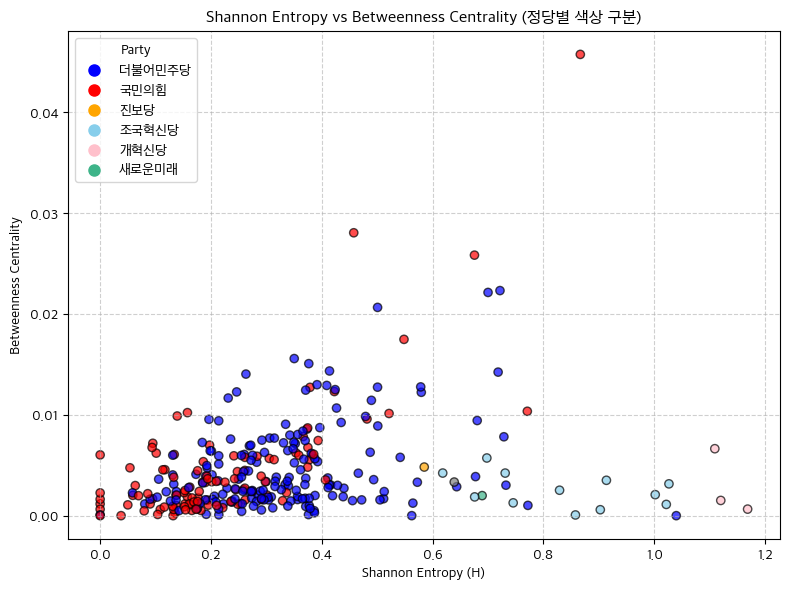

Top 50 nodes for file '의원데이터/전체데이터/제22대_법안별_전체데이터_edge.csv':
 ID Label  Party Reselection District_Type Gender           Role  BetweennessCentrality  ShannonEntropy  AdjustedCentrality   Color
김석기   김석기   국민의힘          3선           지역구      남 Representative           4.573429e-02        0.866563        3.963163e-02     red
한기호   한기호   국민의힘          4선           지역구      남 Representative           2.583069e-02        0.675541        1.744969e-02     red
김준혁   김준혁 더불어민주당          초선           지역구      남 Representative           2.231600e-02        0.721583        1.610284e-02    blue
송기헌   송기헌 더불어민주당          3선           지역구      남 Representative           2.213227e-02        0.700033        1.549332e-02    blue
권영진   권영진   국민의힘          재선           지역구      남 Representative           2.804770e-02        0.457662        1.283638e-02     red
남인순   남인순 더불어민주당          4선           지역구      여 Representative           2.064912e-02        0.500668        1.033835e-02    blue
김병기   김병기 더불어민주

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager, rc

# 엣지와 노드 CSV 파일 목록 정의
edge_files = [
    '의원데이터/전체데이터/제22대_법안별_전체데이터_edge.csv'
]

node_files = [
    '의원데이터/전체데이터/제22대_법안별_전체데이터_node.csv'
]


# 한글 폰트 설정 (예: Apple SD Gothic Neo)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'  # Mac에서 사용 가능한 폰트

# 함수 정의
def calculate_top_nodes_with_entropy_adjusted_centrality(graph, top_n=20):
    """
    Calculate weighted directed betweenness centrality and adjust it by 
    Shannon Entropy of external party connections.
    Return the top N nodes with their full details by the adjusted centrality.
    """
    # Compute weighted directed betweenness centrality
    betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

    adjusted_centrality = {}
    entropies = []
    entropy_centrality_data = []  # For scatter plot
    parties = []  # Track party information for plotting
    top_nodes_details = []  # Store all details for top nodes

    # 노드 개수 상위 두 정당 찾기
    party_counts = pd.Series([graph.nodes[node].get('Party') for node in graph.nodes]).value_counts()
    top_two_parties = party_counts.index[:2]
    party_color_map = {
    '더불어민주당': 'blue',
    '자유한국당': 'red',
    '국민의힘': 'red',
    '국민의당': 'green',
    '열린민주당': 'green',
    '정의당': 'yellow',
    '진보당': 'orange',
    '바른미래당': 'skyblue',
    '기초소득당': 'purple',
    '민주평화당': 'green',
    '조국혁신당': 'skyblue',
    '개혁신당': 'pink',
    '새로운미래': '#3EB489'
    }


    for node in graph.nodes:
        # 정당별 연결 횟수 계산용 카운트 딕셔너리
        party_counts = {}
        node_party = graph.nodes[node].get('Party')

        # 나가는 연결 확인
        for neighbor in graph.neighbors(node):  # Outgoing edges
            neighbor_party = graph.nodes[neighbor].get('Party')
            party_counts[neighbor_party] = party_counts.get(neighbor_party, 0) + 1

        # 들어오는 연결 확인
        for neighbor in graph.predecessors(node):  # Incoming edges
            neighbor_party = graph.nodes[neighbor].get('Party')
            party_counts[neighbor_party] = party_counts.get(neighbor_party, 0) + 1

        # 정당별 총 연결 수 계산
        total_connections = sum(party_counts.values())

        if total_connections > 0:
            # 각 정당별 비율 \( p_i \) 계산 (내부+외부 연결 포함)
            ps = [count / total_connections for count in party_counts.values()]
            # Shannon Entropy 계산 (ln 사용)
            H = -sum(p * np.log(p) for p in ps)
        else:
            H = 0

        entropies.append(H)
        parties.append(node_party)  # Track party for plotting
        log_adjustment_factor = H
        adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Add data for scatter plot
        entropy_centrality_data.append((H, betweenness_centrality[node]))

        # Store details for DataFrame
        top_nodes_details.append({
            'ID': node,
            'Label': graph.nodes[node].get('Label'),
            'Party': node_party,
            'Reselection': graph.nodes[node].get('Reselection'),
            'District_Type': graph.nodes[node].get('District_Type'),
            'Gender': graph.nodes[node].get('Gender'),
            'Role': graph.nodes[node].get('Role'),
            'BetweennessCentrality': betweenness_centrality[node],
            'ShannonEntropy': H,
            'AdjustedCentrality': adjusted_centrality[node],
            'Color': party_color_map.get(node_party, 'gray')  # 미리 지정된 색상 적용
        })

        # 엔트로피와 중심성 산점도 (파일 내 정당만 필터링하여 범례 추가)
    entropy_centrality_data = np.array(entropy_centrality_data)
    used_parties = set(parties)  # 현재 파일에서 사용된 정당
    filtered_party_color_map = {party: color for party, color in party_color_map.items() if party in used_parties}
    colors = [filtered_party_color_map.get(party, 'gray') for party in parties]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(entropy_centrality_data[:, 0], entropy_centrality_data[:, 1],
                        c=colors, alpha=0.7, edgecolors='k')
    plt.title('Shannon Entropy vs Betweenness Centrality (정당별 색상 구분)')
    plt.xlabel('Shannon Entropy (H)')
    plt.ylabel('Betweenness Centrality')
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (파일에 포함된 정당만)
    handles = [plt.Line2D([], [], marker='o', color=color, linestyle='', markersize=8)
            for party, color in filtered_party_color_map.items()]
    labels = list(filtered_party_color_map.keys())
    plt.legend(handles, labels, title="Party", loc='upper left')

    plt.tight_layout()
    plt.show()


    # Create DataFrame
    df = pd.DataFrame(top_nodes_details)

    # 상위 N 노드 정렬
    top_adjusted_centrality = df.sort_values(by='AdjustedCentrality', ascending=False).head(top_n)
    top_betweenness = df.sort_values(by='BetweennessCentrality', ascending=False).head(10)  # 매개 중심성 상위 10
    top_entropy = df.sort_values(by='ShannonEntropy', ascending=False).head(10)  # 샤넌 엔트로피 상위 10

    return top_adjusted_centrality, top_betweenness, top_entropy

# 모든 파일에 대해 처리
for edge_file, node_file in zip(edge_files, node_files):
    # 엣지 데이터 읽기
    edges_df = pd.read_csv(edge_file)
    nodes_df = pd.read_csv(node_file)

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                   Label=row['Label'], 
                   Party=row['Party'],
                   Reselection=row['Reselection'],
                   District_Type=row['District_Type'],
                   Gender=row['Gender'],
                   Role=row['Role'])

    # 엣지 추가 (이미 존재하는 엣지의 가중치 합산)
    for index, row in edges_df.iterrows():
        if G.has_edge(row['Source'], row['Target']):
            # 기존 엣지가 존재하면 가중치 추가
            G[row['Source']][row['Target']]['weight'] += 1
        else:
            # 새 엣지를 추가
            G.add_edge(row['Source'], row['Target'],
                       weight=1,
                       Source_Party=row['Source_Party'],
                       Target_Party=row['Target_Party'],
                       Source_Reselection=row['Source_Reselection'],
                       Target_Reselection=row['Target_Reselection'],
                       Source_District_Type=row['Source_District_Type'],
                       Target_District_Type=row['Target_District_Type'],
                       Source_Gender=row['Source_Gender'],
                       Target_Gender=row['Target_Gender'],
                       Source_Role=row['Source_Role'],
                       Target_Role=row['Target_Role'])

    # 상위 노드 계산 및 시각화
    top_50_nodes_df, top_betweenness_df, top_entropy_df = calculate_top_nodes_with_entropy_adjusted_centrality(G, top_n=300)

    # 결과 출력
    print(f"Top 50 nodes for file '{edge_file}':")
    print(top_50_nodes_df.to_string(index=False))

    # 매개 중심성 상위 10
    print(f"\nTop 10 nodes by Betweenness Centrality for file '{edge_file}':")
    print(top_betweenness_df.to_string(index=False))

    # 샤넌 엔트로피 상위 10
    print(f"\nTop 10 nodes by Shannon Entropy for file '{edge_file}':")
    print(top_entropy_df.to_string(index=False))

    top_50_nodes_df.to_csv("제22대_상위노드.csv",index=False, encoding='utf-8')
